In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
sys.path.append('..')

import src as src
import numpy as np
import matplotlib.pyplot as plt

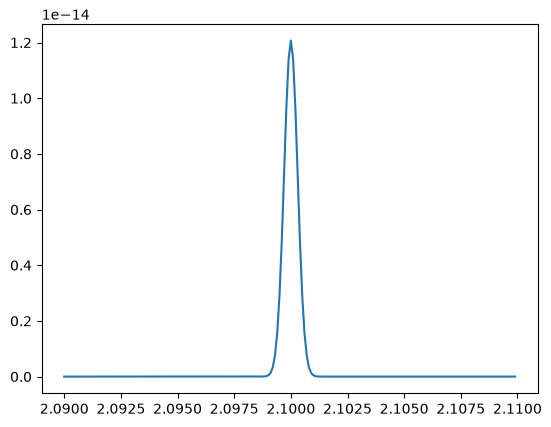

In [5]:
centre = 2.1
flux = 9.0e-18
fwhm = 100
l = np.arange(centre-0.01, centre+0.01, 1e-4)
z=0
wvl, signal = src.emission_line_signal(l, flux, fwhm, centre, z)

plt.plot(wvl, signal)
plt.show()

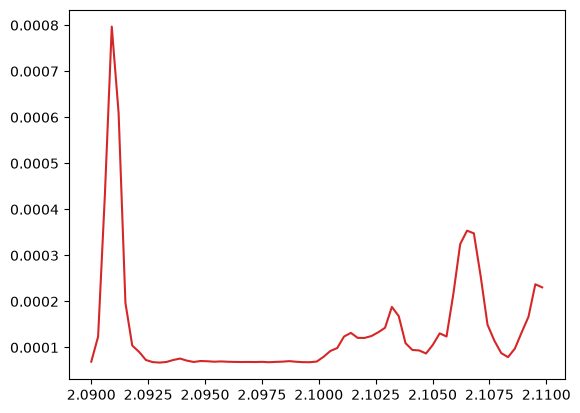

In [6]:
wvl_full, signal_full, thpt, sky, atm = src.bin_signal_thp_atm_sky_data(wvl, signal)

for i in range(len(wvl_full)):
    #plt.plot(wvl_full[i], signal_full[i])
    #plt.plot(wvl_full, thpt)
    plt.plot(wvl_full[i], sky[i])

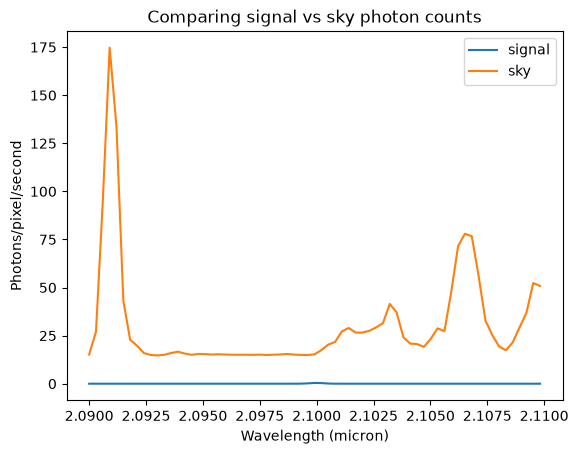

In [7]:
signal_final = src.apply_thpt_atm_to_signal(wvl_full, signal_full, thpt, atm)
sky_final = src.apply_thpt_to_sky(wvl_full, sky, thpt)

area = 0.93 /4* np.pi*650**2
signal_per_pixel = src.calculate_signal_to_photon_counts(wvl_full, signal_final, area)
sky_per_pixel = src.calculate_sky_to_photon_counts(sky_final, area, slit_width=0.84, angular_extent=0.8)

plt.plot(wvl_full[3], signal_per_pixel[3], label = "signal")
plt.plot(wvl_full[3], np.abs(sky_per_pixel[3]), label = "sky")

plt.ylabel("Photons/pixel/second")
plt.xlabel("Wavelength (micron)")

plt.legend()

plt.title("Comparing signal vs sky photon counts")
plt.show()
